<a href="https://colab.research.google.com/github/mohamedragab4554/ML/blob/main/notebooks/how-to-segment-anything-with-sam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# Segment Anything Model (SAM)

---

[![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/facebookresearch/segment-anything) [![arXiv](https://img.shields.io/badge/arXiv-2304.02643-b31b1b.svg)](https://arxiv.org/abs/2304.02643)

Segment Anything Model (SAM): a new AI model from Meta AI that can "cut out" any object, in any image, with a single click. SAM is a promptable segmentation system with zero-shot generalization to unfamiliar objects and images, without the need for additional training. This notebook is an extension of the [official notebook](https://colab.research.google.com/github/facebookresearch/segment-anything/blob/main/notebooks/automatic_mask_generator_example.ipynb) prepared by Meta AI.

![segment anything model](https://media.roboflow.com/notebooks/examples/segment-anything-model-paper.png)

## Complementary Materials

---

[![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/roboflow-ai/notebooks/blob/main/notebooks/how-to-segment-anything-with-sam.ipynb) [![YouTube](https://badges.aleen42.com/src/youtube.svg)](https://youtu.be/D-D6ZmadzPE) [![Roboflow](https://raw.githubusercontent.com/roboflow-ai/notebooks/main/assets/badges/roboflow-blogpost.svg)](https://blog.roboflow.com/how-to-use-segment-anything-model-sam)

We recommend that you follow along in this notebook while reading the blog post on Segment Anything Model.

![segment anything model blogpost](https://media.roboflow.com/notebooks/examples/segment-anything-model-blogpost.png)

## Pro Tip: Use GPU Acceleration

If you are running this notebook in Google Colab, navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`. This will ensure your notebook uses a GPU, which will significantly speed up model training times.

## Steps in this Tutorial

In this tutorial, we are going to cover:

- **Before you start** - Make sure you have access to the GPU
- Install Segment Anything Model (SAM)
- Download Example Data
- Load Model
- Automated Mask Generation
- Generate Segmentation with Bounding Box
- Segment Anything in Roboflow Universe Dataset

## Let's begin!

## Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [25]:
!nvidia-smi

Fri Sep  4 14:43:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [26]:
import os
HOME = os.getcwd()
print("HOME:", HOME)

HOME: /content


## Install Segment Anything Model (SAM) and other dependencies

In [27]:
!pip install -q 'git+https://github.com/facebookresearch/segment-anything.git'

  Preparing metadata (setup.py) ... done


In [28]:
!pip install -q jupyter_bbox_widget roboflow dataclasses-json supervision==0.23.0

### Download SAM weights

In [29]:
!mkdir -p {HOME}/weights
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth -P {HOME}/weights

In [30]:
import os

CHECKPOINT_PATH = os.path.join(HOME, "weights", "sam_vit_h_4b8939.pth")
print(CHECKPOINT_PATH, "; exist:", os.path.isfile(CHECKPOINT_PATH))

/content/weights/sam_vit_h_4b8939.pth ; exist: True


## Download Example Data

**NONE:** Let's download few example images. Feel free to use your images or videos.

In [31]:
!mkdir -p {HOME}/data

!wget -q https://media.roboflow.com/notebooks/examples/dog.jpeg -P {HOME}/data
!wget -q https://media.roboflow.com/notebooks/examples/dog-2.jpeg -P {HOME}/data
!wget -q https://media.roboflow.com/notebooks/examples/dog-3.jpeg -P {HOME}/data
!wget -q https://media.roboflow.com/notebooks/examples/dog-4.jpeg -P {HOME}/data

## Load Model

In [32]:
import torch

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
MODEL_TYPE = "vit_h"

In [33]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH).to(device=DEVICE)

## Automated Mask Generation

To run automatic mask generation, provide a SAM model to the `SamAutomaticMaskGenerator` class. Set the path below to the SAM checkpoint. Running on CUDA and with the default model is recommended.

In [34]:
mask_generator = SamAutomaticMaskGenerator(sam)

In [35]:
import os

IMAGE_NAME = "dog.jpeg"
IMAGE_PATH = os.path.join(HOME, "data", IMAGE_NAME)

### Generate masks with SAM

In [36]:
import cv2
import supervision as sv

image_bgr = cv2.imread(IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

sam_result = mask_generator.generate(image_rgb)

### Output format

`SamAutomaticMaskGenerator` returns a `list` of masks, where each mask is a `dict` containing various information about the mask:

* `segmentation` - `[np.ndarray]` - the mask with `(W, H)` shape, and `bool` type
* `area` - `[int]` - the area of the mask in pixels
* `bbox` - `[List[int]]` - the boundary box of the mask in `xywh` format
* `predicted_iou` - `[float]` - the model's own prediction for the quality of the mask
* `point_coords` - `[List[List[float]]]` - the sampled input point that generated this mask
* `stability_score` - `[float]` - an additional measure of mask quality
* `crop_box` - `List[int]` - the crop of the image used to generate this mask in `xywh` format

In [37]:
print(sam_result[0].keys())

dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])


### Results visualisation with Supervision

As of version `0.5.0` Supervision has native support for SAM.

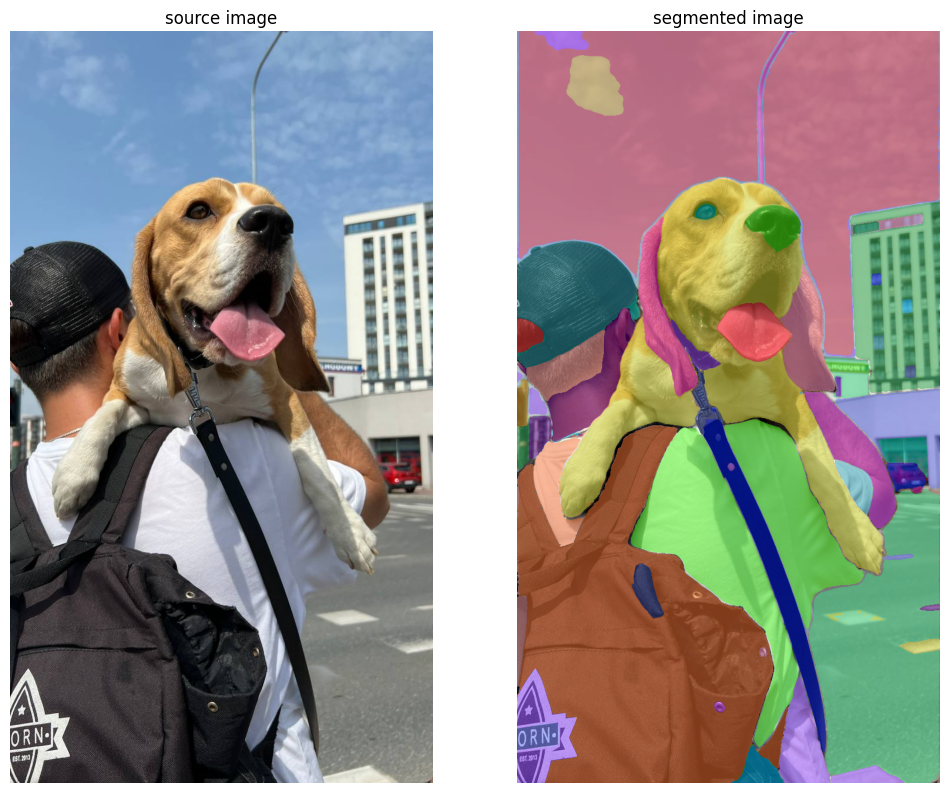

In [38]:
mask_annotator = sv.MaskAnnotator(color_lookup=sv.ColorLookup.INDEX)

detections = sv.Detections.from_sam(sam_result=sam_result)

annotated_image = mask_annotator.annotate(scene=image_bgr.copy(), detections=detections)

sv.plot_images_grid(
    images=[image_bgr, annotated_image],
    grid_size=(1, 2),
    titles=['source image', 'segmented image']
)

### Interaction with segmentation results

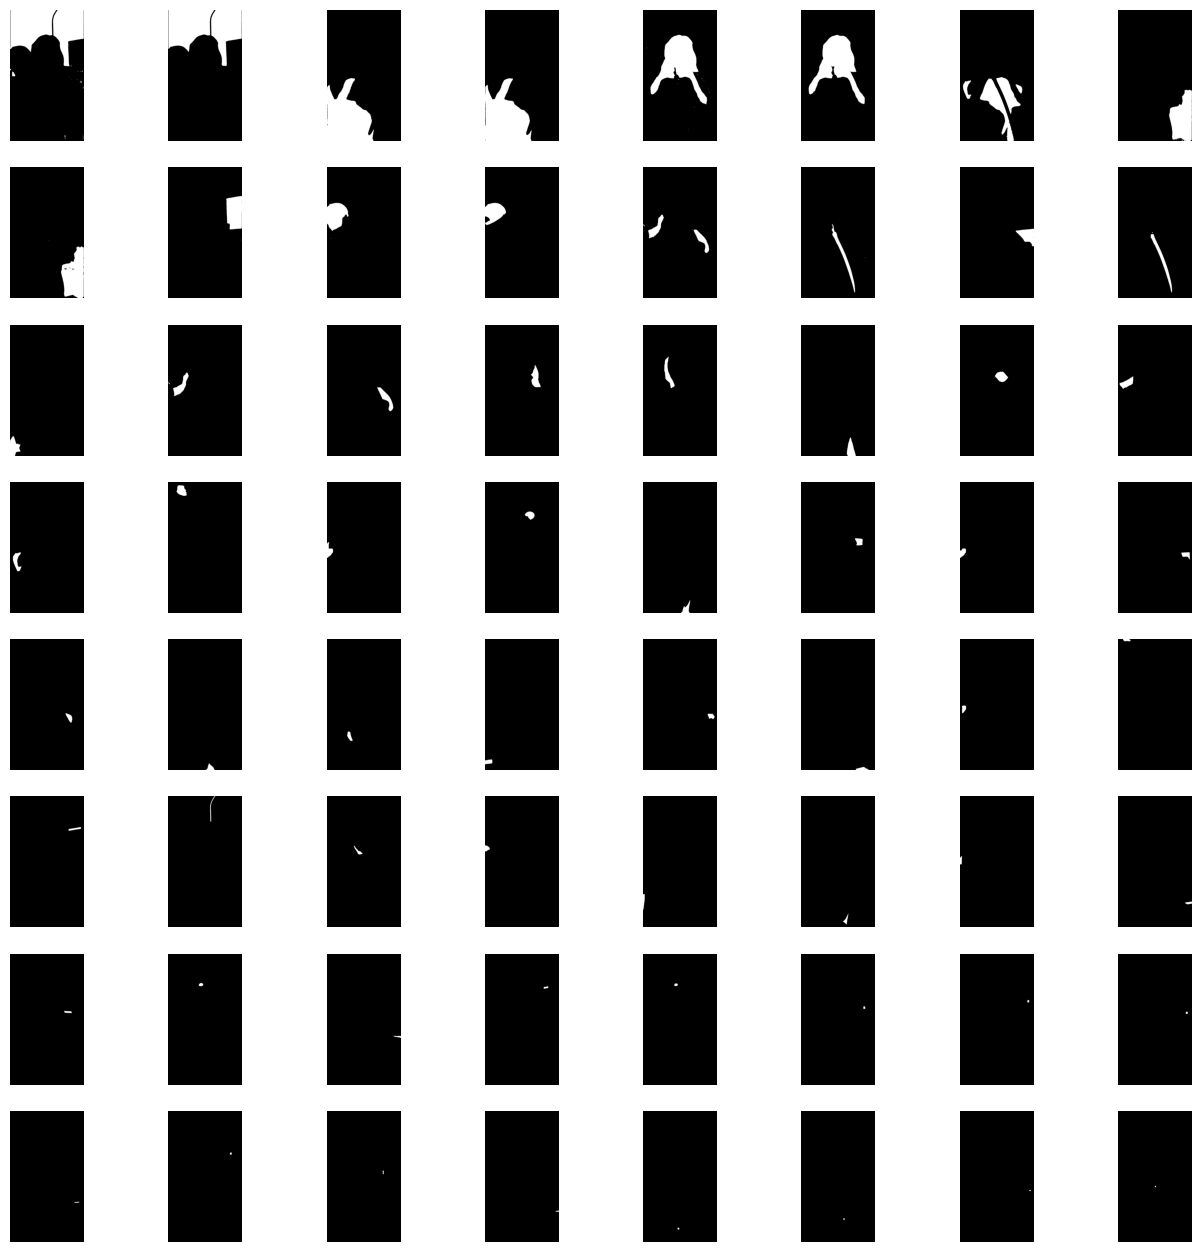

In [39]:
masks = [
    mask['segmentation']
    for mask
    in sorted(sam_result, key=lambda x: x['area'], reverse=True)
]

sv.plot_images_grid(
    images=masks,
    grid_size=(8, int(len(masks) / 8)),
    size=(16, 16)
)

## Generate Segmentation with Bounding Box

The `SamPredictor` class provides an easy interface to the model for prompting the model. It allows the user to first set an image using the `set_image` method, which calculates the necessary image embeddings. Then, prompts can be provided via the `predict` method to efficiently predict masks from those prompts. The model can take as input both point and box prompts, as well as masks from the previous iteration of prediction.

In [40]:
mask_predictor = SamPredictor(sam)

In [41]:
import os

IMAGE_NAME = "dog.jpeg"
IMAGE_PATH = os.path.join(HOME, "data", IMAGE_NAME)

### Draw Box



In [42]:
# helper function that loads an image before adding it to the widget

import base64

def encode_image(filepath):
    with open(filepath, 'rb') as f:
        image_bytes = f.read()
    encoded = str(base64.b64encode(image_bytes), 'utf-8')
    return "data:image/jpg;base64,"+encoded

**NOTE:** Execute cell below and use your mouse to draw bounding box on the image 👇

In [43]:
IS_COLAB = True

if IS_COLAB:
    from google.colab import output
    output.enable_custom_widget_manager()

from jupyter_bbox_widget import BBoxWidget

widget = BBoxWidget()
widget.image = encode_image(IMAGE_PATH)
widget

In [44]:
widget.bboxes

[]

### Generate masks with SAM

**NOTE:** `SamPredictor.predict` method takes `np.ndarray` `box` argument in `[x_min, y_min, x_max, y_max]` format. Let's reorganise your data first

In [45]:
import numpy as np

# default_box is going to be used if you will not draw any box on image above
default_box = {'x': 68, 'y': 247, 'width': 555, 'height': 678, 'label': ''}

box = widget.bboxes[0] if widget.bboxes else default_box
box = np.array([
    box['x'],
    box['y'],
    box['x'] + box['width'],
    box['y'] + box['height']
])

In [46]:
import cv2
import numpy as np
import supervision as sv

image_bgr = cv2.imread(IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

mask_predictor.set_image(image_rgb)

masks, scores, logits = mask_predictor.predict(
    box=box,
    multimask_output=True
)

### Results visualisation with Supervision

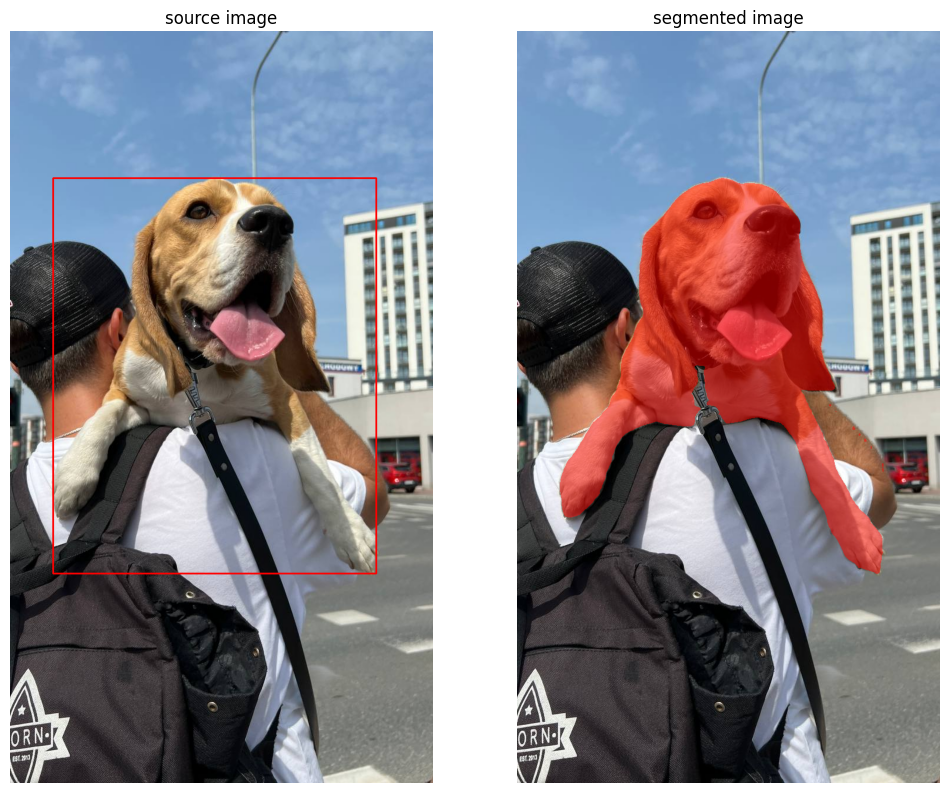

In [47]:
box_annotator = sv.BoxAnnotator(color=sv.Color.RED, color_lookup=sv.ColorLookup.INDEX)
mask_annotator = sv.MaskAnnotator(color=sv.Color.RED, color_lookup=sv.ColorLookup.INDEX)

detections = sv.Detections(
    xyxy=sv.mask_to_xyxy(masks=masks),
    mask=masks
)
detections = detections[detections.area == np.max(detections.area)]

source_image = box_annotator.annotate(scene=image_bgr.copy(), detections=detections)
segmented_image = mask_annotator.annotate(scene=image_bgr.copy(), detections=detections)

sv.plot_images_grid(
    images=[source_image, segmented_image],
    grid_size=(1, 2),
    titles=['source image', 'segmented image']
)

### Interaction with segmentation results

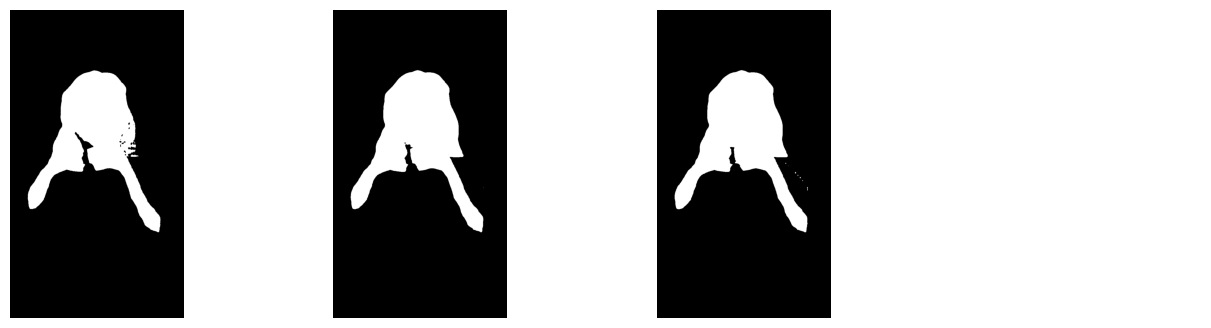

In [48]:
import supervision as v

sv.plot_images_grid(
    images=masks,
    grid_size=(1, 4),
    size=(16, 4)
)

## Segment Anything in Roboflow Universe Dataset

### Utils Supporting Dataset Processing

A couple of helper functions that, unfortunately, we have to write ourselves to facilitate the processing of COCO annotations.

In [49]:
import numpy as np
from dataclasses import dataclass
from typing import List, Tuple, Union, Optional
from dataclasses_json import dataclass_json
from supervision import Detections


@dataclass_json
@dataclass
class COCOCategory:
    id: int
    name: str
    supercategory: str


@dataclass_json
@dataclass
class COCOImage:
    id: int
    width: int
    height: int
    file_name: str
    license: int
    date_captured: str
    coco_url: Optional[str] = None
    flickr_url: Optional[str] = None


@dataclass_json
@dataclass
class COCOAnnotation:
    id: int
    image_id: int
    category_id: int
    segmentation: List[List[float]]
    area: float
    bbox: Tuple[float, float, float, float]
    iscrowd: int


@dataclass_json
@dataclass
class COCOLicense:
    id: int
    name: str
    url: str


@dataclass_json
@dataclass
class COCOJson:
    images: List[COCOImage]
    annotations: List[COCOAnnotation]
    categories: List[COCOCategory]
    licenses: List[COCOLicense]


def load_coco_json(json_file: str) -> COCOJson:
    import json

    with open(json_file, "r") as f:
        json_data = json.load(f)

    return COCOJson.from_dict(json_data)


class COCOJsonUtility:
    @staticmethod
    def get_annotations_by_image_id(coco_data: COCOJson, image_id: int) -> List[COCOAnnotation]:
        return [annotation for annotation in coco_data.annotations if annotation.image_id == image_id]

    @staticmethod
    def get_annotations_by_image_path(coco_data: COCOJson, image_path: str) -> Optional[List[COCOAnnotation]]:
        image = COCOJsonUtility.get_image_by_path(coco_data, image_path)
        if image:
            return COCOJsonUtility.get_annotations_by_image_id(coco_data, image.id)
        else:
            return None

    @staticmethod
    def get_image_by_path(coco_data: COCOJson, image_path: str) -> Optional[COCOImage]:
        for image in coco_data.images:
            if image.file_name == image_path:
                return image
        return None

    @staticmethod
    def annotations2detections(annotations: List[COCOAnnotation]) -> Detections:
        class_id, xyxy = [], []

        for annotation in annotations:
            x_min, y_min, width, height = annotation.bbox
            class_id.append(annotation.category_id)
            xyxy.append([
                x_min,
                y_min,
                x_min + width,
                y_min + height
            ])

        return Detections(
            xyxy=np.array(xyxy, dtype=int),
            class_id=np.array(class_id, dtype=int)
        )

### Download Dataset from Roboflow

In [50]:
%cd {HOME}

import roboflow
from roboflow import Roboflow

roboflow.login()

rf = Roboflow()

project = rf.workspace("hashira-fhxpj").project("mri-brain-tumor")
dataset = project.version(1).download("coco")

/content
visit https://app.roboflow.com/auth-cli to get your authentication token.


KeyboardInterrupt: Interrupted by user

In [ ]:
import os

DATA_SET_SUBDIRECTORY = "test"
ANNOTATIONS_FILE_NAME = "_annotations.coco.json"
IMAGES_DIRECTORY_PATH = os.path.join(dataset.location, DATA_SET_SUBDIRECTORY)
ANNOTATIONS_FILE_PATH = os.path.join(dataset.location, DATA_SET_SUBDIRECTORY, ANNOTATIONS_FILE_NAME)

In [51]:
coco_data = load_coco_json(json_file=ANNOTATIONS_FILE_PATH)

CLASSES = [
    category.name
    for category
    in coco_data.categories
    if category.supercategory != 'none'
]

IMAGES = [
    image.file_name
    for image
    in coco_data.images
]

NameError: name 'ANNOTATIONS_FILE_PATH' is not defined

In [ ]:
CLASSES

### Single Image Bounding Box to Mask

In [ ]:
# set random seed to allow easy reproduction of the experiment

import random
random.seed(10)

In [ ]:
EXAMPLE_IMAGE_NAME = random.choice(IMAGES)
EXAMPLE_IMAGE_PATH = os.path.join(dataset.location, DATA_SET_SUBDIRECTORY, EXAMPLE_IMAGE_NAME)

# load dataset annotations
annotations = COCOJsonUtility.get_annotations_by_image_path(coco_data=coco_data, image_path=EXAMPLE_IMAGE_NAME)
ground_truth = COCOJsonUtility.annotations2detections(annotations=annotations)

# small hack - coco numerate classes from 1, model from 0 + we drop first redundant class from coco json
ground_truth.class_id = ground_truth.class_id - 1

# load image
image_bgr = cv2.imread(EXAMPLE_IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# initiate annotator
box_annotator = sv.BoxAnnotator(color=sv.Color.RED, color_lookup=sv.ColorLookup.INDEX)
mask_annotator = sv.MaskAnnotator(color=sv.Color.RED, color_lookup=sv.ColorLookup.INDEX)

# annotate ground truth
annotated_frame_ground_truth = box_annotator.annotate(scene=image_bgr.copy(), detections=ground_truth)

# run SAM inference
mask_predictor.set_image(image_rgb)

masks, scores, logits = mask_predictor.predict(
    box=ground_truth.xyxy[0],
    multimask_output=True
)

detections = sv.Detections(
    xyxy=sv.mask_to_xyxy(masks=masks),
    mask=masks
)
detections = detections[detections.area == np.max(detections.area)]

annotated_image = mask_annotator.annotate(scene=image_bgr.copy(), detections=detections)

sv.plot_images_grid(
    images=[annotated_frame_ground_truth, annotated_image],
    grid_size=(1, 2),
    titles=['source image', 'segmented image']
)

## 🏆 Congratulations

### Learning Resources

Roboflow has produced many resources that you may find interesting as you advance your knowledge of computer vision:

- [Roboflow Notebooks](https://github.com/roboflow/notebooks): A repository of over 20 notebooks that walk through how to train custom models with a range of model types, from YOLOv7 to SegFormer.
- [Roboflow YouTube](https://www.youtube.com/c/Roboflow): Our library of videos featuring deep dives into the latest in computer vision, detailed tutorials that accompany our notebooks, and more.
- [Roboflow Discuss](https://discuss.roboflow.com/): Have a question about how to do something on Roboflow? Ask your question on our discussion forum.
- [Roboflow Models](https://roboflow.com): Learn about state-of-the-art models and their performance. Find links and tutorials to guide your learning.

### Convert data formats

Roboflow provides free utilities to convert data between dozens of popular computer vision formats. Check out [Roboflow Formats](https://roboflow.com/formats) to find tutorials on how to convert data between formats in a few clicks.

### Connect computer vision to your project logic

[Roboflow Templates](https://roboflow.com/templates) is a public gallery of code snippets that you can use to connect computer vision to your project logic. Code snippets range from sending emails after inference to measuring object distance between detections.

## Test with User Provided Images

First, let's download the images you provided from Google Drive. **IMPORTANT:** Ensure both images in your Google Drive are shared with 'Anyone with the link' (Viewer or Editor access) for the download to succeed.

In [52]:
# Install gdown for downloading from Google Drive if not already installed
!pip install -q gdown

In [53]:
# Install additional required libraries. Ensuring they are present for the rest of the notebook.
!pip install -q jupyter_bbox_widget roboflow dataclasses-json supervision==0.23.0

In [54]:
import os

# HOME is already defined globally. `supervision`, `jupyter_bbox_widget`, etc., are installed in dedicated cells.
# This cell focuses solely on downloading user images.

USER_IMAGES_DIR = os.path.join(HOME, 'user_data')
!mkdir -p {USER_IMAGES_DIR}

# Download the first image
!gdown --id 14a3oPZgIHm9yGWCT6kRCYhuqkz8u8X6M -O {USER_IMAGES_DIR}/user_image_1.jpeg

# Download the second image
!gdown --id 1Eui8wXr-b6yyHDZwcM_d2SndZWi2eNc6 -O {USER_IMAGES_DIR}/user_image_2.jpeg

print(f"Images downloaded to: {USER_IMAGES_DIR}")

/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=14a3oPZgIHm9yGWCT6kRCYhuqkz8u8X6M
To: /content/user_data/user_image_1.jpeg
100% 46.7k/46.7k [00:00<00:00, 67.6MB/s]
/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1Eui8wXr-b6yyHDZwcM_d2SndZWi2eNc6
To: /content/user_data/user_image_2.jpeg
100% 75.0k/75.0k [00:00<00:00, 2.46MB/s]
Images downloaded to: /content/user_data


### Automated Mask Generation for User Image 1

### Automated Mask Generation for User Image 1

Generating masks for /content/user_data/user_image_1.jpeg...


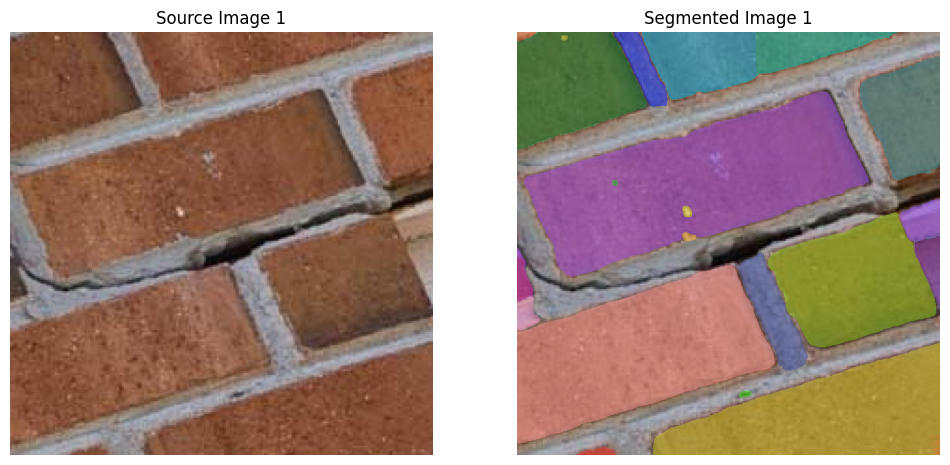

In [55]:
import cv2
import supervision as sv

USER_IMAGE_1_PATH = os.path.join(USER_IMAGES_DIR, "user_image_1.jpeg")

image_bgr_user1 = cv2.imread(USER_IMAGE_1_PATH)

# Add a check to ensure the image was loaded successfully
if image_bgr_user1 is None:
    print(f"Error: Image not loaded from {USER_IMAGE_1_PATH}. Please check file path and permissions.")
else:
    image_rgb_user1 = cv2.cvtColor(image_bgr_user1, cv2.COLOR_BGR2RGB)

    print(f"Generating masks for {USER_IMAGE_1_PATH}...")
    sam_result_user1 = mask_generator.generate(image_rgb_user1)

    mask_annotator = sv.MaskAnnotator(color_lookup=sv.ColorLookup.INDEX)
    detections_user1 = sv.Detections.from_sam(sam_result=sam_result_user1)

    annotated_image_user1 = mask_annotator.annotate(scene=image_bgr_user1.copy(), detections=detections_user1)

    sv.plot_images_grid(
        images=[image_bgr_user1, annotated_image_user1],
        grid_size=(1, 2),
        titles=['Source Image 1', 'Segmented Image 1']
    )

### Automated Mask Generation for User Image 2

### Automated Mask Generation for User Image 2

Generating masks for /content/user_data/user_image_2.jpeg...


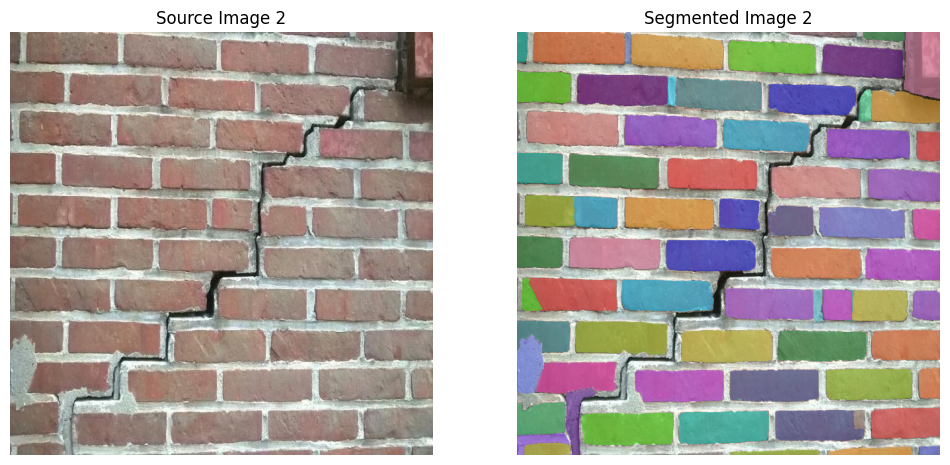

In [56]:
import cv2
import supervision as sv

USER_IMAGE_2_PATH = os.path.join(USER_IMAGES_DIR, "user_image_2.jpeg")

image_bgr_user2 = cv2.imread(USER_IMAGE_2_PATH)

# Add a check to ensure the image was loaded successfully
if image_bgr_user2 is None:
    print(f"Error: Image not loaded from {USER_IMAGE_2_PATH}. Please check file path and permissions.")
else:
    image_rgb_user2 = cv2.cvtColor(image_bgr_user2, cv2.COLOR_BGR2RGB)

    print(f"Generating masks for {USER_IMAGE_2_PATH}...")
    sam_result_user2 = mask_generator.generate(image_rgb_user2)

    mask_annotator = sv.MaskAnnotator(color_lookup=sv.ColorLookup.INDEX)
    detections_user2 = sv.Detections.from_sam(sam_result=sam_result_user2)

    annotated_image_user2 = mask_annotator.annotate(scene=image_bgr_user2.copy(), detections=detections_user2)

    sv.plot_images_grid(
        images=[image_bgr_user2, annotated_image_user2],
        grid_size=(1, 2),
        titles=['Source Image 2', 'Segmented Image 2']
    )

### Generate Segmentation with Bounding Box for User Image 1

**NOTE:** Execute the cell below and use your mouse to draw a bounding box on the image. You might need to run the cell twice if the widget doesn't appear on the first attempt.

### Generate Segmentation with Bounding Box for User Image 1

**NOTE:** Execute the cell below and use your mouse to draw a bounding box on the image. You might need to run the cell twice if the widget doesn't appear on the first attempt.

In [57]:
import base64
from jupyter_bbox_widget import BBoxWidget
from google.colab import output
import os

def encode_image(filepath):
    with open(filepath, 'rb') as f:
        image_bytes = f.read()
    encoded = str(base64.b64encode(image_bytes), 'utf-8')
    return "data:image/jpg;base64,"+encoded

output.enable_custom_widget_manager()

if not os.path.exists(USER_IMAGE_1_PATH):
    print(f"Error: Image file not found at {USER_IMAGE_1_PATH}. Please ensure it downloaded successfully.")
else:
    widget_user1 = BBoxWidget()
    widget_user1.image = encode_image(USER_IMAGE_1_PATH)
    print("Please draw a bounding box on the image below.")
    widget_user1

Please draw a bounding box on the image below.


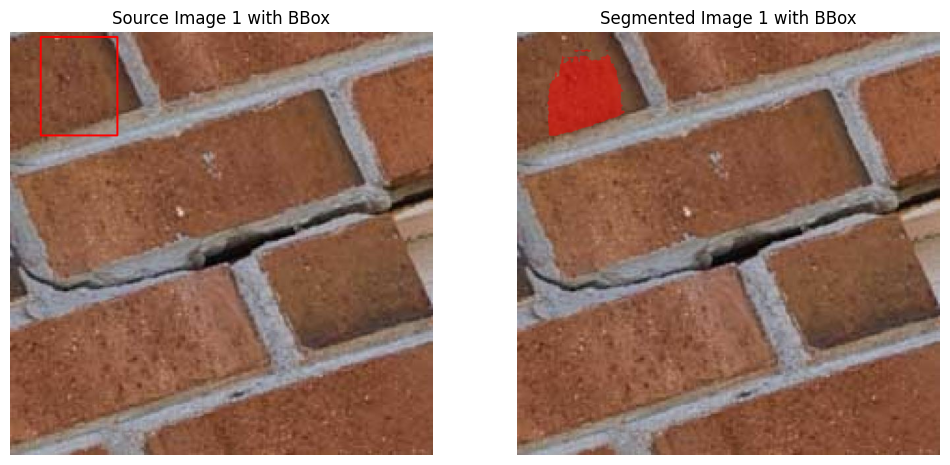

In [58]:
import numpy as np
import cv2
import supervision as sv

# Retrieve the drawn bounding box for user_image_1
# Use a default box if no box is drawn
default_box_user1 = {'x': 50, 'y': 50, 'width': 100, 'height': 100, 'label': ''}
box_user1 = widget_user1.bboxes[0] if widget_user1.bboxes else default_box_user1

box_np_user1 = np.array([
    box_user1['x'],
    box_user1['y'],
    box_user1['x'] + box_user1['width'],
    box_user1['y'] + box_user1['height']
])

image_bgr_user1_bbox = cv2.imread(USER_IMAGE_1_PATH)

# Add a check to ensure the image was loaded successfully
if image_bgr_user1_bbox is None:
    print(f"Error: Image not loaded from {USER_IMAGE_1_PATH}. Please check file path and permissions.")
else:
    image_rgb_user1_bbox = cv2.cvtColor(image_bgr_user1_bbox, cv2.COLOR_BGR2RGB)

    mask_predictor.set_image(image_rgb_user1_bbox)

    masks_user1, scores_user1, logits_user1 = mask_predictor.predict(
        box=box_np_user1,
        multimask_output=True
    )

    box_annotator = sv.BoxAnnotator(color=sv.Color.RED, color_lookup=sv.ColorLookup.INDEX)
    mask_annotator = sv.MaskAnnotator(color=sv.Color.RED, color_lookup=sv.ColorLookup.INDEX)

    detections_user1_bbox = sv.Detections(
        xyxy=sv.mask_to_xyxy(masks=masks_user1),
        mask=masks_user1
    )
    detections_user1_bbox = detections_user1_bbox[detections_user1_bbox.area == np.max(detections_user1_bbox.area)]

    source_image_user1_bbox = box_annotator.annotate(scene=image_bgr_user1_bbox.copy(), detections=detections_user1_bbox)
    segmented_image_user1_bbox = mask_annotator.annotate(scene=image_bgr_user1_bbox.copy(), detections=detections_user1_bbox)

    sv.plot_images_grid(
        images=[source_image_user1_bbox, segmented_image_user1_bbox],
        grid_size=(1, 2),
        titles=['Source Image 1 with BBox', 'Segmented Image 1 with BBox']
    )

### Generate Segmentation with Bounding Box for User Image 2

**NOTE:** Execute the cell below and use your mouse to draw a bounding box on the image. You might need to run the cell twice if the widget doesn't appear on the first attempt.

### Generate Segmentation with Bounding Box for User Image 2

**NOTE:** Execute the cell below and use your mouse to draw a bounding box on the image. You might need to run the cell twice if the widget doesn't appear on the first attempt.

In [59]:
import base64
from jupyter_bbox_widget import BBoxWidget
from google.colab import output
import os

def encode_image(filepath):
    with open(filepath, 'rb') as f:
        image_bytes = f.read()
    encoded = str(base64.b64encode(image_bytes), 'utf-8')
    return "data:image/jpg;base64,"+encoded

output.enable_custom_widget_manager()

if not os.path.exists(USER_IMAGE_2_PATH):
    print(f"Error: Image file not found at {USER_IMAGE_2_PATH}. Please ensure it downloaded successfully.")
else:
    widget_user2 = BBoxWidget()
    widget_user2.image = encode_image(USER_IMAGE_2_PATH)
    print("Please draw a bounding box on the image below.")
    widget_user2

Please draw a bounding box on the image below.


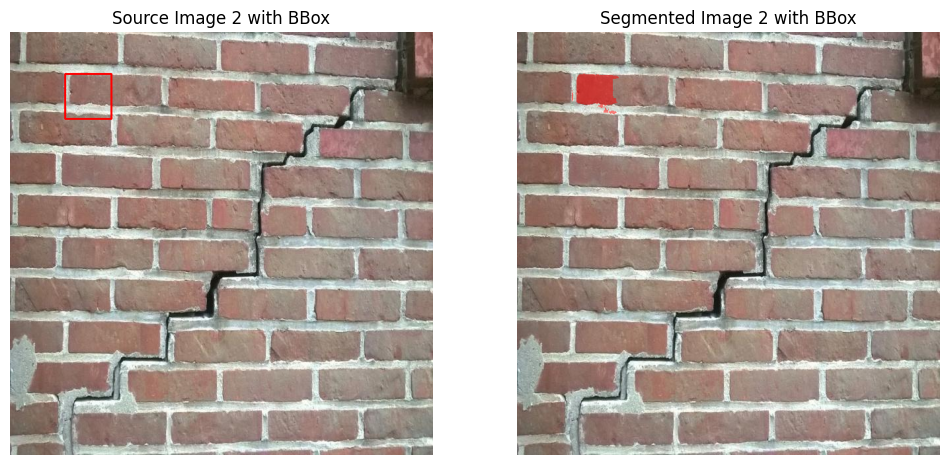

In [60]:
import numpy as np
import cv2
import supervision as sv

# Retrieve the drawn bounding box for user_image_2
# Use a default box if no box is drawn
default_box_user2 = {'x': 50, 'y': 50, 'width': 100, 'height': 100, 'label': ''}
box_user2 = widget_user2.bboxes[0] if widget_user2.bboxes else default_box_user2

box_np_user2 = np.array([
    box_user2['x'],
    box_user2['y'],
    box_user2['x'] + box_user2['width'],
    box_user2['y'] + box_user2['height']
])

image_bgr_user2_bbox = cv2.imread(USER_IMAGE_2_PATH)

# Add a check to ensure the image was loaded successfully
if image_bgr_user2_bbox is None:
    print(f"Error: Image not loaded from {USER_IMAGE_2_PATH}. Please check file path and permissions.")
else:
    image_rgb_user2_bbox = cv2.cvtColor(image_bgr_user2_bbox, cv2.COLOR_BGR2RGB)

    mask_predictor.set_image(image_rgb_user2_bbox)

    masks_user2, scores_user2, logits_user2 = mask_predictor.predict(
        box=box_np_user2,
        multimask_output=True
    )

    box_annotator = sv.BoxAnnotator(color=sv.Color.RED, color_lookup=sv.ColorLookup.INDEX)
    mask_annotator = sv.MaskAnnotator(color=sv.Color.RED, color_lookup=sv.ColorLookup.INDEX)

    detections_user2_bbox = sv.Detections(
        xyxy=sv.mask_to_xyxy(masks=masks_user2),
        mask=masks_user2
    )
    detections_user2_bbox = detections_user2_bbox[detections_user2_bbox.area == np.max(detections_user2_bbox.area)]

    source_image_user2_bbox = box_annotator.annotate(scene=image_bgr_user2_bbox.copy(), detections=detections_user2_bbox)
    segmented_image_user2_bbox = mask_annotator.annotate(scene=image_bgr_user2_bbox.copy(), detections=detections_user2_bbox)

    sv.plot_images_grid(
        images=[source_image_user2_bbox, segmented_image_user2_bbox],
        grid_size=(1, 2),
        titles=['Source Image 2 with BBox', 'Segmented Image 2 with BBox']
    )